In [1]:
import xarray as xr
import glob

files = glob.glob('C:/Users/grace.UOPNET/Desktop/data/*.nc')

# Load dataset, ensure times decoded properly
data = xr.open_mfdataset(files, combine='by_coords', decode_times=True)


In [2]:
sst = data['analysed_sst']

# Check latitude ordering before slicing:
print(sst.latitude.values[:10])  # if increasing from south to north, use 5 to 25


[9.474999 9.525    9.575    9.625    9.675    9.724999 9.775    9.825
 9.875    9.925   ]


In [3]:
sst_bob = sst.sel(latitude=slice(5, 25), longitude=slice(80, 100))


In [4]:
sst_bob_time = sst_bob.sel(time=slice('2014-05-30', '2022-12-31'))


In [5]:
sst_bob_mean = sst_bob_time.mean(dim=['latitude', 'longitude'], skipna=True)


In [6]:
sst_monthly = sst_bob_mean.resample(time='1M').mean()


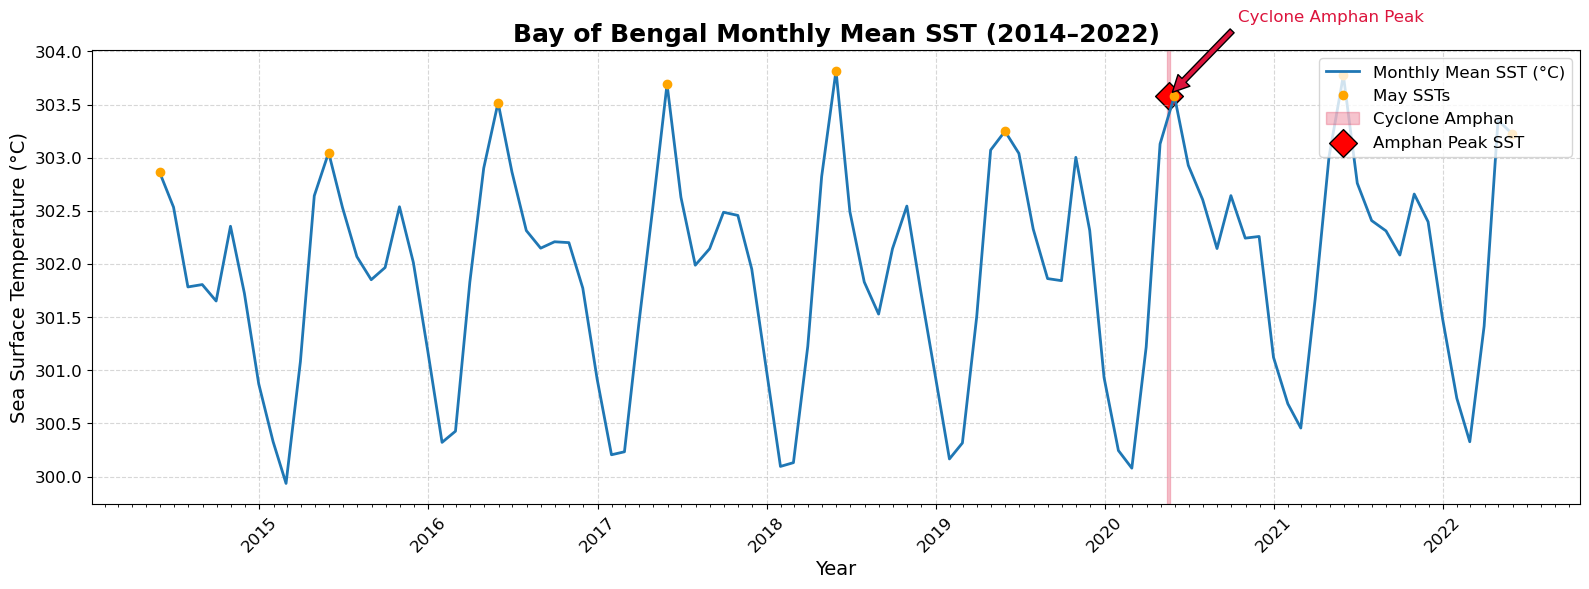

In [22]:
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.dates as mdates

# Amphan peak date
amphan_date = pd.Timestamp('2020-05-19')
amphan_sst = sst_monthly.sel(time=amphan_date, method='nearest').values

# Filter SST values for May only
sst_may = sst_monthly.sel(time=sst_monthly['time.month'] == 5)

# Create figure and axis
fig, ax = plt.subplots(figsize=(16, 6))

# Plot full SST time series
ax.plot(sst_monthly['time'].values, sst_monthly.values,
        label='Monthly Mean SST (°C)', color='#1f77b4', linewidth=2)

# Highlight May SSTs with markers
ax.plot(sst_may['time'].values, sst_may.values,
        marker='o', linestyle='None', color='orange', markersize=6, label='May SSTs')

# Highlight Cyclone Amphan period (May 16–21, 2020)
ax.axvspan(pd.Timestamp('2020-05-16'), pd.Timestamp('2020-05-21'),
           color='crimson', alpha=0.25, label='Cyclone Amphan')

# Big diamond marker at Amphan peak SST
ax.scatter(amphan_date, amphan_sst, s=200, marker='D', color='red', edgecolor='black', label='Amphan Peak SST')

# Annotate Amphan peak with arrow
ax.annotate('Cyclone Amphan Peak',
            xy=(amphan_date, amphan_sst),
            xytext=(amphan_date + pd.Timedelta(days=150), amphan_sst + 0.7),
            arrowprops=dict(facecolor='crimson', shrink=0.05),
            fontsize=12, color='crimson')

# Titles and labels
ax.set_title('Bay of Bengal Monthly Mean SST (2014–2022)', fontsize=18, weight='bold')
ax.set_xlabel('Year', fontsize=14)
ax.set_ylabel('Sea Surface Temperature (°C)', fontsize=14)

# Format x-axis ticks (major = years, minor = months)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_minor_locator(mdates.MonthLocator())
ax.tick_params(axis='x', rotation=45, labelsize=12)
ax.tick_params(axis='y', labelsize=12)

# Grid and legend
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(fontsize=12, loc='upper right')

plt.tight_layout()
plt.show()
